<a href="https://colab.research.google.com/github/rajneeshpandeyseo-a11y/property-price-prediction/blob/main/Unsupervised_ML_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

# load and Read Dataset

df = pd.read_csv("/content/drive/MyDrive/Data Science Carrior 247/Unsupervised_machine_learning/unsupervised_dataset/Clustering_Marketing.csv")
df.head(20)

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0
5,2008,M,18.034,32,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2006,M,18.53,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
7,2006,F,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2006,F,19.168,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,2007,NaN,NaN,21,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

In [ ]:
df['gender'] = df['gender'].map({
    'M': 1,
    'F': 0
})

In [ ]:
# Fill missing keyword values with 0
df["gender"] = df["gender"].fillna(0).inplace=True

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           15000 non-null  bool  
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

In [ ]:
df["age"] = pd.to_numeric(df["age"], errors='coerce')

In [ ]:
# Handle age (replace missing with median)
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
# convert columns in integers
df['age'] = df['age'].astype(int)

In [ ]:
# convert columns in integers
df['gender'] = df['gender'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gradyear         15000 non-null  int64
 1   gender           15000 non-null  int64
 2   age              15000 non-null  int64
 3   NumberOffriends  15000 non-null  int64
 4   basketball       15000 non-null  int64
 5   football         15000 non-null  int64
 6   soccer           15000 non-null  int64
 7   softball         15000 non-null  int64
 8   volleyball       15000 non-null  int64
 9   swimming         15000 non-null  int64
 10  cheerleading     15000 non-null  int64
 11  baseball         15000 non-null  int64
 12  tennis           15000 non-null  int64
 13  sports           15000 non-null  int64
 14  cute             15000 non-null  int64
 15  sex              15000 non-null  int64
 16  sexy             15000 non-null  int64
 17  hot              15000 non-null  int64
 18  kissed

In [ ]:
df.describe()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,15000.0,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2007.496933,1.0,17.397267,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,0.0,6.965095,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,1.0,4.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,1.0,16.000000,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,1.0,17.000000,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,1.0,18.000000,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,1.0,106.000000,605.000000,22.000000,9.000000,22.00000,17.000000,14.000000,31.000000,...,327.000000,12.000000,11.000000,8.000000,8.000000,8.000000,16.000000,14.000000,8.000000,16.000000


In [ ]:
# Feature Scaling

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

In [ ]:
# Elbow Method to find best number of cluster

wcss = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

In [ ]:
print(wcss)

[556299.8776996573, 545145.6468776258, 531808.4846225963, 519622.96072578494, 512381.0919704485, 500368.0925289912, 482688.5523527118, 472783.7793977678]


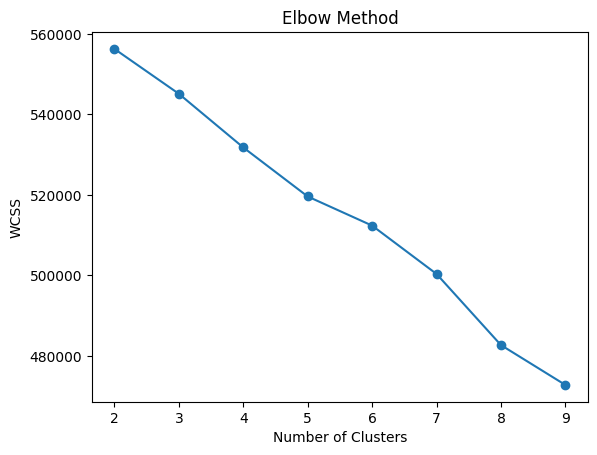

In [ ]:
plt.figure()
plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
# K-Means Clustering

k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
cluster_profile = df.groupby('Cluster').mean()
print(cluster_profile)

            gradyear  gender        age  NumberOffriends  basketball  \
Cluster                                                                
0        2007.620758     1.0  17.277445        31.143713    0.566866   
1        2006.494792     1.0  18.805339        25.140137    0.121094   
2        2007.825688     1.0  17.025229        38.759174    0.403670   
3        2007.686306     1.0  16.919951        43.013816    0.742381   
4        2008.502015     1.0  16.068157        28.343349    0.178454   

         football    soccer  softball  volleyball  swimming  ...    blonde  \
Cluster                                                      ...             
0        0.532934  0.399202  0.217565    0.197605  0.267465  ...  1.181637   
1        0.130534  0.118815  0.070475    0.059896  0.083333  ...  0.039551   
2        0.383028  0.298165  0.160550    0.261468  0.266055  ...  0.222477   
3        0.750508  0.571312  0.534336    0.441284  0.281999  ...  0.186103   
4        0.137230  0.158300

In [ ]:
# PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

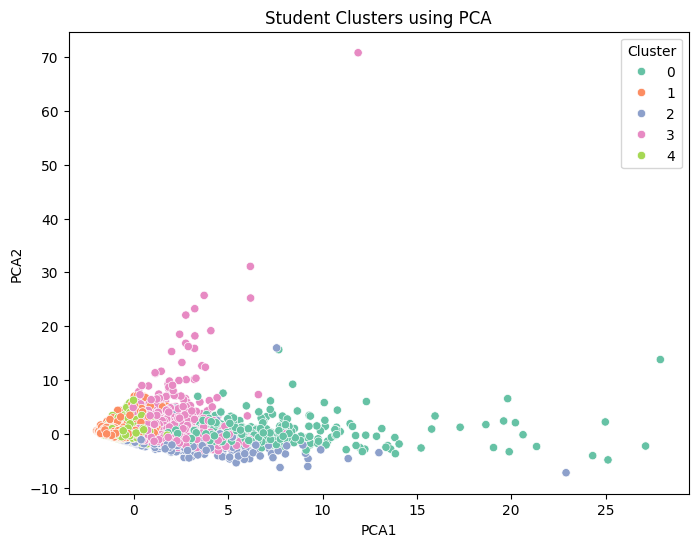

In [ ]:
# PCA Cluster Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2',
    data=df
)
plt.title("Student Clusters using PCA")
plt.show()